In [43]:
import os
import sys
import cv2
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "./.."))
sys.path.append(PROJECT_ROOT)
from app.modelsAI.insightFace.model import cosine_sim, app
from app.modelsAI.unet.segmentaion import segment_face
import matplotlib.pyplot as plt
from app.utils.cropImage import cropImage
import xml.etree.ElementTree as ET


import xml.etree.ElementTree as ET

def parse_voc_xml(xml_path):
    """
    Đọc bounding box từ file VOC XML và gán nhãn số:
    0 = without_mask
    1 = with_mask
    2 = mask_weared_incorrect
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []
    labels = []

    for obj in root.findall("object"):
        name = obj.find("name").text.strip()  # with_mask / without_mask / mask_weared_incorrect
        bnd = obj.find("bndbox")
        xmin = int(bnd.find("xmin").text)
        ymin = int(bnd.find("ymin").text)
        xmax = int(bnd.find("xmax").text)
        ymax = int(bnd.find("ymax").text)

        boxes.append((xmin, ymin, xmax, ymax))

        # Gán nhãn số cho 3 class
        if name == "with_mask":
            labels.append(1)
        elif name == "without_mask":
            labels.append(0)
        elif name == "mask_weared_incorrect":
            labels.append(1)
        else:
            raise ValueError(f"Unknown class name: {name}")

    return boxes, labels
def iou(boxA, boxB):
    """
    Tính IoU giữa 2 bounding box.
    boxA, boxB: tuple hoặc list (x1, y1, x2, y2)
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # Tính diện tích giao nhau
    interWidth = max(0, xB - xA)
    interHeight = max(0, yB - yA)
    interArea = interWidth * interHeight

    # Diện tích từng box
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    # IoU
    iou_value = interArea / float(boxAArea + boxBArea - interArea + 1e-6)  # +1e-6 để tránh chia 0
    return iou_value

In [38]:
import os
import cv2
from app.modelsAI.unet.segmentaion import segment_face
from app.utils.cropImage import cropImage

imagesTest = r"/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/dataset/tesst/images"
labelsTest = r"/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/dataset/tesst/annotations"

y_true = []
y_pred = []
y_score = []
totalface = 0
THRESHOLD = 0.7
count = 1

IOU_THRESHOLD = 0.5

for name in os.listdir(imagesTest):

    img = cv2.imread(os.path.join(imagesTest, name))
    xml_path = os.path.join(labelsTest, name.replace(".png", ".xml"))
    if img is None or not os.path.exists(xml_path):
        continue

    gt_boxes, gt_labels = parse_voc_xml(xml_path)
    faces = app.get(img)

    matched_gt = set()

    for face in faces:
        pb = tuple(map(int, face.bbox))

        best_iou = 0
        best_gt = -1

        for i, gb in enumerate(gt_boxes):
            if i in matched_gt:
                continue
            iou_val = iou(pb, gb)
            if iou_val > best_iou:
                best_iou = iou_val
                best_gt = i

        # --- match thành công ---
        if best_iou >= IOU_THRESHOLD:
            matched_gt.add(best_gt)
            true_label = gt_labels[best_gt]

            face_crop = cropImage(img, pb)
            pred_mask = segment_face(face_crop)
            score = pred_mask.mean()
            pred_label = 1 if score > THRESHOLD else 0

            y_true.append(true_label)
            y_pred.append(pred_label)
            y_score.append(score)

        else:
            pass

        print(f"[{count}] GT={true_label} | Pred={pred_label} | Score={score:.3f}")
        count += 1

/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/venv/lib/python3.11/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


[1] GT=1 | Pred=1 | Score=1.000
[2] GT=1 | Pred=1 | Score=1.000
[3] GT=1 | Pred=1 | Score=1.000
[4] GT=1 | Pred=1 | Score=1.000
[5] GT=1 | Pred=1 | Score=1.000
[6] GT=1 | Pred=1 | Score=1.000
[7] GT=1 | Pred=1 | Score=1.000
[8] GT=1 | Pred=1 | Score=1.000
[9] GT=1 | Pred=1 | Score=1.000
[10] GT=0 | Pred=1 | Score=1.000
[11] GT=0 | Pred=0 | Score=0.000
[12] GT=0 | Pred=0 | Score=0.000
[13] GT=1 | Pred=1 | Score=1.000
[14] GT=1 | Pred=1 | Score=1.000
[15] GT=1 | Pred=1 | Score=1.000
[16] GT=0 | Pred=1 | Score=1.000
[17] GT=1 | Pred=1 | Score=1.000
[18] GT=1 | Pred=1 | Score=1.000
[19] GT=1 | Pred=1 | Score=1.000
[20] GT=1 | Pred=1 | Score=1.000
[21] GT=1 | Pred=1 | Score=1.000
[22] GT=1 | Pred=1 | Score=1.000
[23] GT=1 | Pred=1 | Score=1.000
[24] GT=1 | Pred=0 | Score=0.000
[25] GT=0 | Pred=0 | Score=0.000
[26] GT=1 | Pred=1 | Score=1.000
[27] GT=1 | Pred=1 | Score=1.000
[28] GT=1 | Pred=1 | Score=1.000
[29] GT=1 | Pred=1 | Score=1.000
[30] GT=1 | Pred=1 | Score=1.000
[31] GT=1 | Pred=1 

libpng warning: iCCP: Not recognizing known sRGB profile that has been edited


[1868] GT=1 | Pred=1 | Score=1.000
[1869] GT=1 | Pred=1 | Score=1.000
[1870] GT=1 | Pred=1 | Score=1.000
[1871] GT=1 | Pred=1 | Score=1.000
[1872] GT=1 | Pred=1 | Score=1.000
[1873] GT=1 | Pred=1 | Score=1.000
[1874] GT=1 | Pred=1 | Score=1.000
[1875] GT=1 | Pred=1 | Score=1.000
[1876] GT=1 | Pred=1 | Score=1.000
[1877] GT=1 | Pred=1 | Score=1.000
[1878] GT=1 | Pred=1 | Score=1.000
[1879] GT=1 | Pred=1 | Score=1.000
[1880] GT=1 | Pred=1 | Score=1.000
[1881] GT=1 | Pred=1 | Score=1.000
[1882] GT=1 | Pred=1 | Score=1.000
[1883] GT=1 | Pred=1 | Score=1.000
[1884] GT=0 | Pred=0 | Score=0.000
[1885] GT=1 | Pred=1 | Score=1.000
[1886] GT=1 | Pred=1 | Score=1.000
[1887] GT=1 | Pred=1 | Score=1.000
[1888] GT=1 | Pred=1 | Score=1.000
[1889] GT=1 | Pred=1 | Score=1.000
[1890] GT=1 | Pred=1 | Score=1.000
[1891] GT=1 | Pred=1 | Score=1.000
[1892] GT=1 | Pred=1 | Score=1.000
[1893] GT=1 | Pred=1 | Score=1.000
[1894] GT=1 | Pred=1 | Score=1.000
[1895] GT=1 | Pred=1 | Score=1.000
[1896] GT=1 | Pred=1

In [33]:
import numpy as np

y_true = np.array(y_true)
y_pred = np.array(y_pred)

TP = np.sum((y_true == 1) & (y_pred == 1))
TN = np.sum((y_true == 0) & (y_pred == 0))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))

accuracy  = (TP + TN) / (TP + TN + FP + FN + 1e-8)
precision = TP / (TP + FP + 1e-8)
recall    = TP / (TP + FN + 1e-8)
f1_score  = 2 * precision * recall / (precision + recall + 1e-8)

print("TP:", TP, "FP:", FP, "FN:", FN, "TN:", TN)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1_score:.4f}")

TP: 2613 FP: 669 FN: 5 TN: 55
Accuracy : 0.7983
Precision: 0.7962
Recall   : 0.9981
F1-score : 0.8858


In [40]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true, y_pred,
    target_names=["No Mask", "Mask"]
))

              precision    recall  f1-score   support

     No Mask       0.85      0.08      0.15       619
        Mask       0.83      1.00      0.90      2723

    accuracy                           0.83      3342
   macro avg       0.84      0.54      0.53      3342
weighted avg       0.83      0.83      0.76      3342



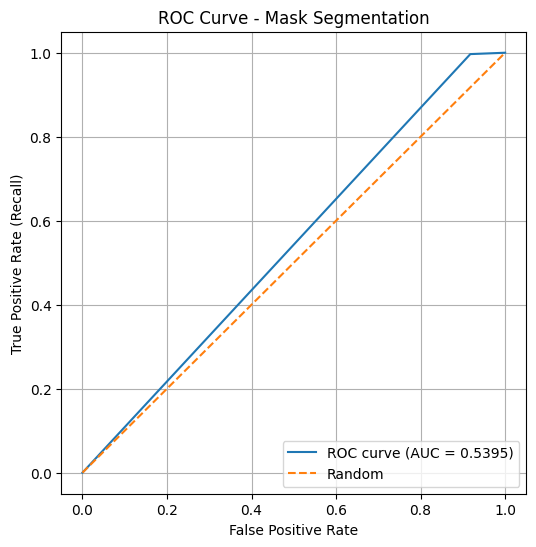

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_true = np.array(y_true)
y_score = np.array(y_score)

# ROC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Mask Segmentation")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

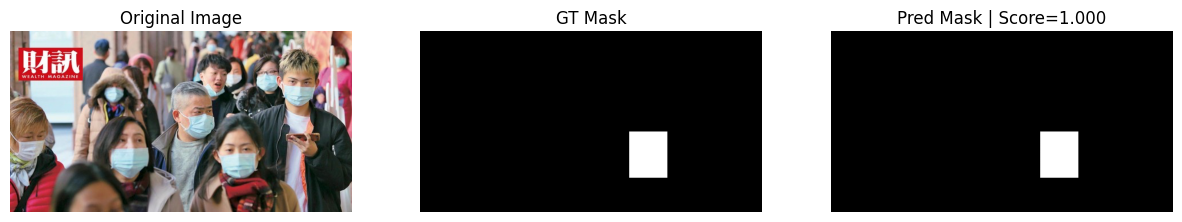

[2] GT=1 | Pred=1 | Score=1.000


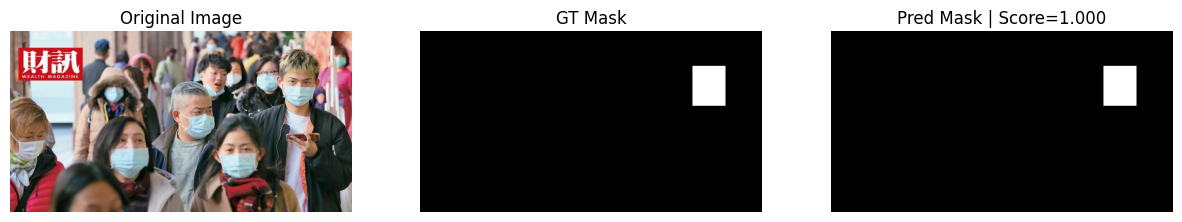

[3] GT=1 | Pred=1 | Score=1.000


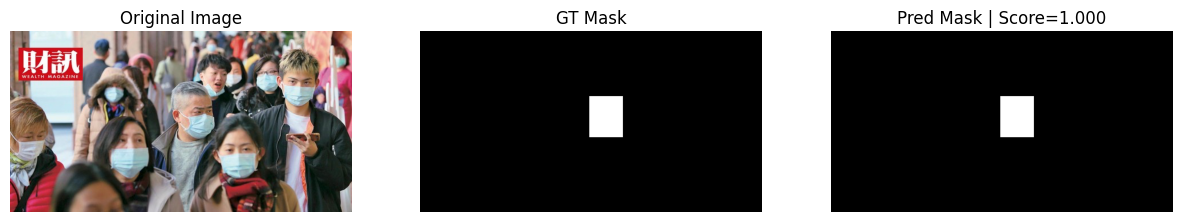

[4] GT=1 | Pred=1 | Score=1.000


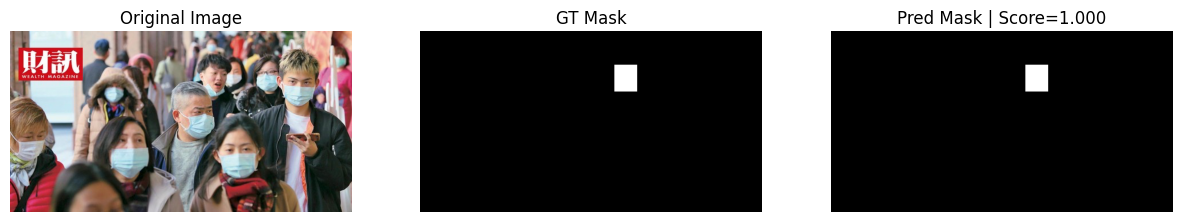

[5] GT=1 | Pred=1 | Score=1.000


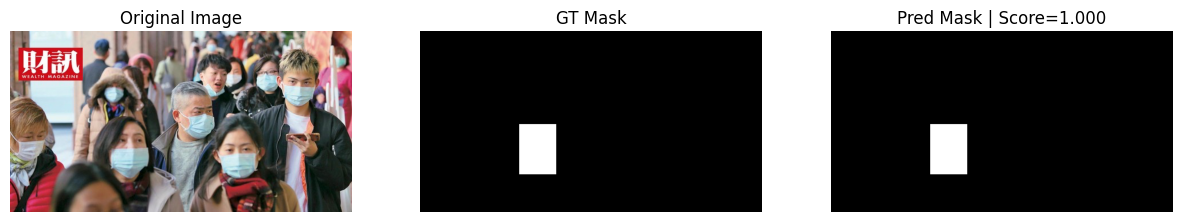

[6] GT=1 | Pred=1 | Score=1.000
[7] GT=1 | Pred=1 | Score=1.000
[8] GT=1 | Pred=1 | Score=1.000
[9] GT=1 | Pred=1 | Score=1.000
[10] GT=1 | Pred=1 | Score=1.000
[11] GT=0 | Pred=1 | Score=1.000
[12] GT=0 | Pred=0 | Score=0.000
[13] GT=0 | Pred=0 | Score=0.000
[14] GT=1 | Pred=1 | Score=1.000
[15] GT=1 | Pred=1 | Score=1.000
[16] GT=1 | Pred=1 | Score=1.000
[17] GT=0 | Pred=1 | Score=1.000
[18] GT=1 | Pred=1 | Score=1.000
[19] GT=1 | Pred=1 | Score=1.000
[20] GT=1 | Pred=1 | Score=1.000
[21] GT=1 | Pred=1 | Score=1.000
[22] GT=1 | Pred=1 | Score=1.000
[23] GT=1 | Pred=1 | Score=1.000
[24] GT=1 | Pred=1 | Score=1.000
[25] GT=1 | Pred=0 | Score=0.000
[26] GT=0 | Pred=0 | Score=0.000
[27] GT=1 | Pred=1 | Score=1.000
[28] GT=1 | Pred=1 | Score=1.000
[29] GT=1 | Pred=1 | Score=1.000
[30] GT=1 | Pred=1 | Score=1.000
[31] GT=1 | Pred=1 | Score=1.000
[32] GT=1 | Pred=1 | Score=1.000
[33] GT=1 | Pred=1 | Score=1.000
[34] GT=1 | Pred=1 | Score=1.000
[35] GT=1 | Pred=1 | Score=1.000
[36] GT=1 | Pr

KeyboardInterrupt: 

In [46]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from app.modelsAI.unet.segmentaion import segment_face
from app.utils.cropImage import cropImage

imagesTest = r"/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/dataset/tesst/images"
labelsTest = r"/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/dataset/tesst/annotations"

THRESHOLD = 0.7
IOU_THRESHOLD = 0.5
count = 1
MAX_DISPLAY = 2  # chỉ hiển thị 5 mặt đầu

for name in os.listdir(imagesTest):

    img_path = os.path.join(imagesTest, name)
    xml_path = os.path.join(labelsTest, name.replace(".png", ".xml"))

    img = cv2.imread(img_path)
    if img is None or not os.path.exists(xml_path):
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt_boxes, gt_labels = parse_voc_xml(xml_path)
    faces = app.get(img)
    matched_gt = set()

    for face in faces:
        pb = tuple(map(int, face.bbox))

        best_iou = 0
        best_gt = -1
        for i, gb in enumerate(gt_boxes):
            if i in matched_gt:
                continue
            iou_val = iou(pb, gb)
            if iou_val > best_iou:
                best_iou = iou_val
                best_gt = i

        if best_iou >= IOU_THRESHOLD:
            matched_gt.add(best_gt)
            true_label = gt_labels[best_gt]

            # --- crop face và dự đoán mask ---
            face_crop = cropImage(img, pb)
            pred_mask = segment_face(face_crop)
            pred_mask = np.array(pred_mask, dtype=np.float32)  # fix lỗi resize
            score = pred_mask.mean()
            pred_label = 1 if score > THRESHOLD else 0

            # --- hiển thị trực quan ---
            if count <= MAX_DISPLAY:
                # Tạo mask GT
                gt_mask = np.zeros(img.shape[:2], dtype=np.uint8)
                x1, y1, x2, y2 = pb
                gt_mask[y1:y2, x1:x2] = 255

                # Resize prediction mask về bbox
                pred_mask_resized = cv2.resize(pred_mask, (x2-x1, y2-y1))
                pred_mask_resized = (pred_mask_resized > 0.5).astype(np.uint8) * 255
                pred_mask_full = np.zeros(img.shape[:2], dtype=np.uint8)
                pred_mask_full[y1:y2, x1:x2] = pred_mask_resized

                # Hiển thị
                fig, axes = plt.subplots(1, 3, figsize=(15,5))
                axes[0].imshow(img_rgb)
                axes[0].set_title("Original Image")
                axes[0].axis("off")

                axes[1].imshow(gt_mask, cmap='gray')
                axes[1].set_title("GT Mask")
                axes[1].axis("off")

                axes[2].imshow(pred_mask_full, cmap='gray')
                axes[2].set_title(f"Pred Mask | Score={score:.3f}")
                axes[2].axis("off")

                plt.show()

            count += 1

            print(f"[{count}] GT={true_label} | Pred={pred_label} | Score={score:.3f}")